## This notebook analyzes the historical performance of the SPY ETF, including price trends, monthly returns, cumulative returns, and rolling volatility.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load & Inspect Data

In [3]:
df = pd.read_csv(
    r"D:\ACC102\SPY.csv",
    index_col="Date",
    parse_dates=True
)
print("===== Data Preview =====")
print(df.head())

print("\n===== Descriptive Statistics =====")
print(df.describe())

===== Data Preview =====
              Open    High     Low   Close  Adj Close      Volume
Date                                                             
2023-01-31  384.68  419.62  377.83  410.75     404.56  1792562300
2023-02-28  413.98  431.53  406.98  430.21     423.67  1512345600
2023-03-31  431.53  454.52  421.73  454.52     447.38  1487654300
2023-04-30  454.11  462.19  440.55  457.23     449.98  1234567800
2023-05-31  457.32  470.11  445.22  466.12     458.65  1321654700

===== Descriptive Statistics =====
             Open        High         Low       Close   Adj Close  \
count   40.000000   40.000000   40.000000   40.000000   40.000000   
mean   585.653750  601.344000  574.318250  593.615000  583.084750   
std    106.313783  105.596134  106.520723  103.144373  100.656032   
min    384.680000  419.620000  377.830000  410.750000  404.560000   
25%    485.075000  498.547500  474.635000  493.715000  485.592500   
50%    585.030000  601.720000  568.640000  589.380000  578.8900

## 3. Data Preprocessing

In [4]:
df = df.dropna()
df = df.sort_index()

## 4. Calculate Key Financial Metrics

In [6]:
df["Monthly_Return"] = df["Close"].pct_change()

df["Cumulative_Return"] = (1 + df["Monthly_Return"]).cumprod()

df["Volatility"] = df["Monthly_Return"].rolling(12).std() * np.sqrt(12)

df = df.dropna()

## 5. Display Key Performance Results

In [7]:
print("\n===== Key Analysis Results =====")
print(f"Total Cumulative Return: {df['Cumulative_Return'].iloc[-1] - 1:.2%}")
print(f"Average Monthly Return: {df['Monthly_Return'].mean():.2%}")
print(f"Annualized Return: {df['Monthly_Return'].mean() * 12:.2%}")
print(f"Annualized Volatility: {df['Volatility'].iloc[-1]:.2%}")


===== Key Analysis Results =====
Total Cumulative Return: 73.15%
Average Monthly Return: 1.25%
Annualized Return: 15.05%
Annualized Volatility: 4.79%


## 6. Visualize Results

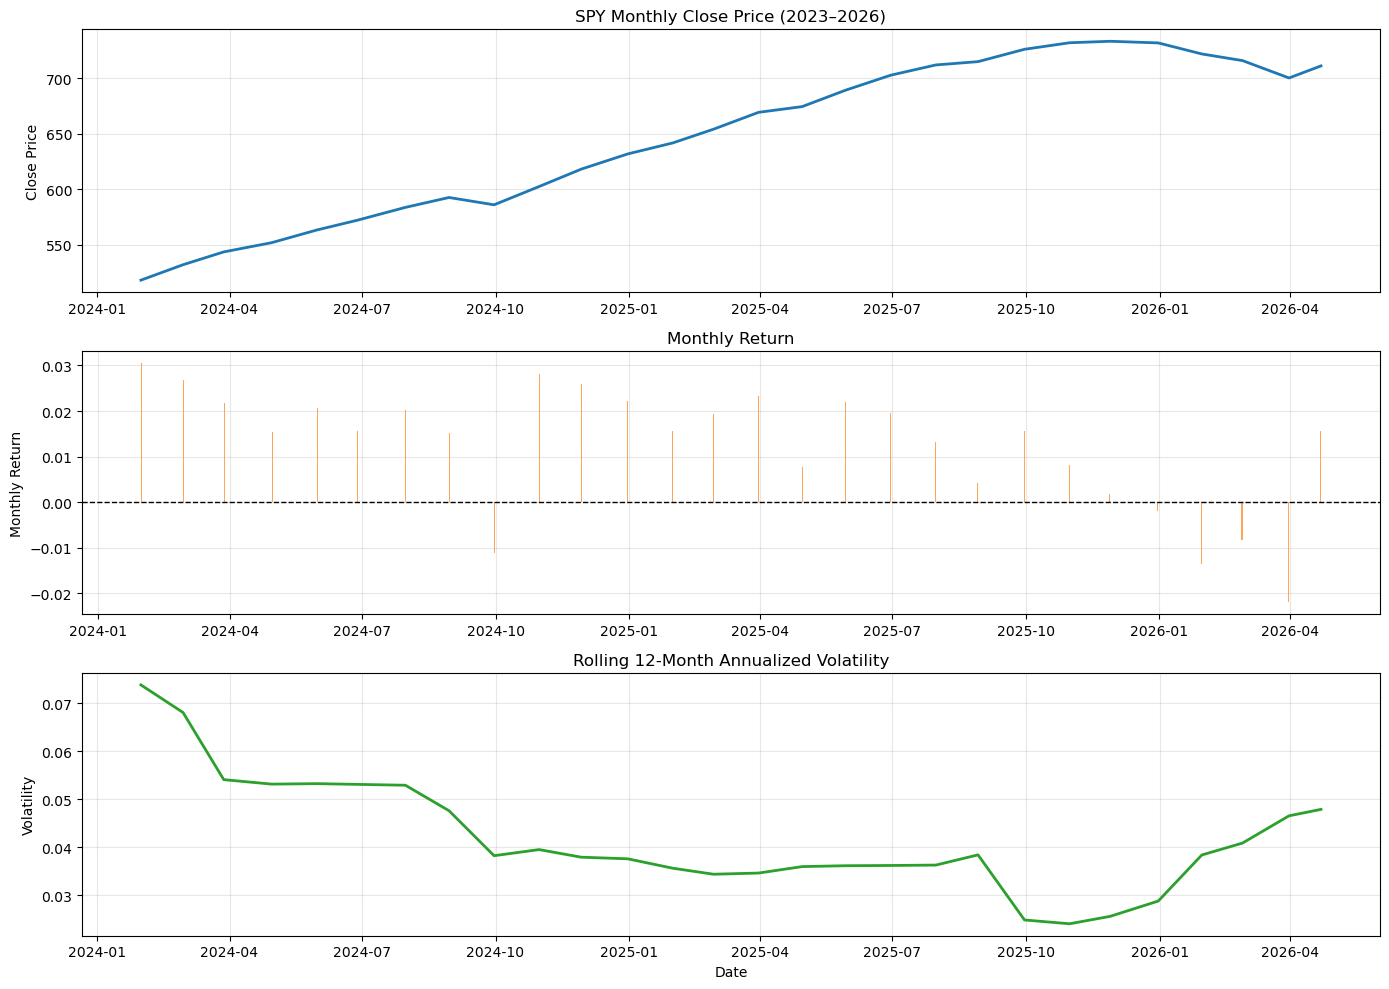

In [8]:

plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

plt.subplot(3, 1, 1)
plt.plot(df["Close"], color="#1f77b4", linewidth=2)
plt.title("SPY Monthly Close Price (2023–2026)", fontsize=12)
plt.ylabel("Close Price")

plt.subplot(3, 1, 2)
plt.bar(df.index, df["Monthly_Return"], color="#ff7f0e", alpha=0.7)
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.title("Monthly Return", fontsize=12)
plt.ylabel("Monthly Return")

plt.subplot(3, 1, 3)
plt.plot(df["Volatility"], color="#2ca02c", linewidth=2)
plt.title("Rolling 12-Month Annualized Volatility", fontsize=12)
plt.ylabel("Volatility")
plt.xlabel("Date")

plt.tight_layout()
plt.show()